In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
columns=["Sample code number",            
"Clump Thickness"    ,           
"Uniformity of Cell Size",       
"Uniformity of Cell Shape",      
"Marginal Adhesion",             
"Single Epithelial Cell Size",   
"Bare Nuclei",                   
"Bland Chromatin",               
"Normal Nucleoli" ,              
"Mitoses",                       
"Class"]

dataset = pd. read_csv ('./breast+cancer+wisconsin+original/breast-cancer-wisconsin.data', names=columns,na_values='?')
dataset=dataset.dropna()

x = dataset . iloc [:, 1:-1]. values
y = dataset . iloc [:, -1]. values

In [3]:
print(np. any ( np. isnan ( x )) )
print(np. any ( np. isnan ( y )) )

False
False


In [4]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [5]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state=0)
classifier . fit(x_train, y_train)
LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=0, solver=' lbfgs ', tol=0.0001, verbose=0,
                   warm_start=False)

LogisticRegression(multi_class='auto', random_state=0, solver=' lbfgs ')

In [6]:
y_pred = classifier. predict ( x_test )
y_pred[ 0 : 10 ]

array([2, 2, 2, 2, 4, 2, 2, 2, 4, 2])

In [7]:
comparison = np. concatenate (( y_test .reshape( -1 , 1 ), y_pred .reshape( -1 , 1
)), axis = 1 )
#comparing the real values vs predictions
comparison [ 0 : 10 ,:]

array([[2, 2],
       [2, 2],
       [4, 2],
       [2, 2],
       [4, 4],
       [2, 2],
       [2, 2],
       [2, 2],
       [4, 4],
       [2, 2]])

In [8]:
from sklearn . metrics import confusion_matrix
cm = confusion_matrix ( y_test, y_pred)
print ( cm )

[[88  2]
 [ 4 43]]


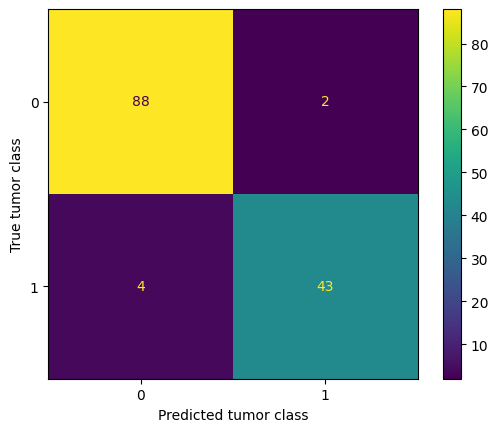

In [9]:
from sklearn . metrics import ConfusionMatrixDisplay

display=ConfusionMatrixDisplay ( confusion_matrix=cm ,display_labels=["0","1"] )
display.plot()
plt .xlabel("Predicted tumor class")
plt .ylabel("True tumor class")
plt .show()

In [10]:
from sklearn . model_selection import cross_val_score
accuracies = cross_val_score ( estimator = classifier , X = x_train , y = y_train , cv
=10 )
print ("Accuracy : {: .4f} %".format( accuracies . mean () *100 ))
print ("Standard Deviation : {:.4f} %".format( accuracies. std () *100 ))

Accuracy :  96.5219 %
Standard Deviation : 3.4216 %
